# 01 - Exploratory Data Analysis (EDA)
## Explainable Machine Learning for Breast Cancer Risk Prediction

Notebook ini khusus untuk eksplorasi data (EDA) sebelum masuk ke tahap pemodelan.
Pemodelan untuk masing-masing algoritma (SVM, XGBoost, Random Forest) dipisah ke notebook tersendiri:
- `02_SVM.ipynb`
- `03_XGBoost.ipynb`
- `04_RandomForest.ipynb`
- `05_Model_Comparison.ipynb` (perbandingan akhir ketiga model)

**Dataset:** Wisconsin Breast Cancer Diagnostic Dataset (569 sampel, 30 fitur numerik hasil digitalisasi citra FNA).


## 1. Import Library

In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

RANDOM_STATE = 42
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Library dasar berhasil diimpor.')


Library dasar berhasil diimpor.


## 2. Memuat Dataset

In [2]:

df = pd.read_csv('data/breast-cancer.csv')
print('Ukuran dataset:', df.shape)
df.head()


Ukuran dataset: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:

print('Total missing value:', df.isnull().sum().sum())
print('Jumlah baris duplikat:', df.duplicated().sum())


Total missing value: 0
Jumlah baris duplikat: 0


In [5]:

df = df.drop(columns=['id'])
df.describe().T


,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## 3. Distribusi Kelas Target (Diagnosis)

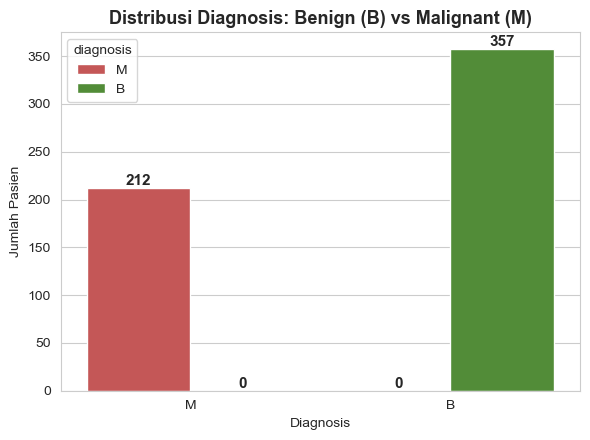

diagnosis
B    62.74 %
M    37.26 %
Name: proportion, dtype: object


In [7]:

plt.figure(figsize=(6,4.5))
ax = sns.countplot(data=df, x='diagnosis', hue='diagnosis',
                    palette={'B': '#4C9A2A', 'M': '#D64545'})
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title('Distribusi Diagnosis: Benign (B) vs Malignant (M)', fontsize=13, fontweight='bold')
plt.xlabel('Diagnosis')
plt.ylabel('Jumlah Pasien')
plt.tight_layout()
plt.show()

print(df['diagnosis'].value_counts(normalize=True).mul(100).round(2).astype(str) + ' %')


> Terdapat sedikit ketidakseimbangan kelas (62.7% Benign vs 37.3% Malignant), masih wajar sehingga tidak perlu resampling khusus. Kita gunakan `stratify` pada split dan metrik yang tahan imbalance (F1, ROC-AUC).

## 4. Distribusi Fitur Utama (`_mean`)

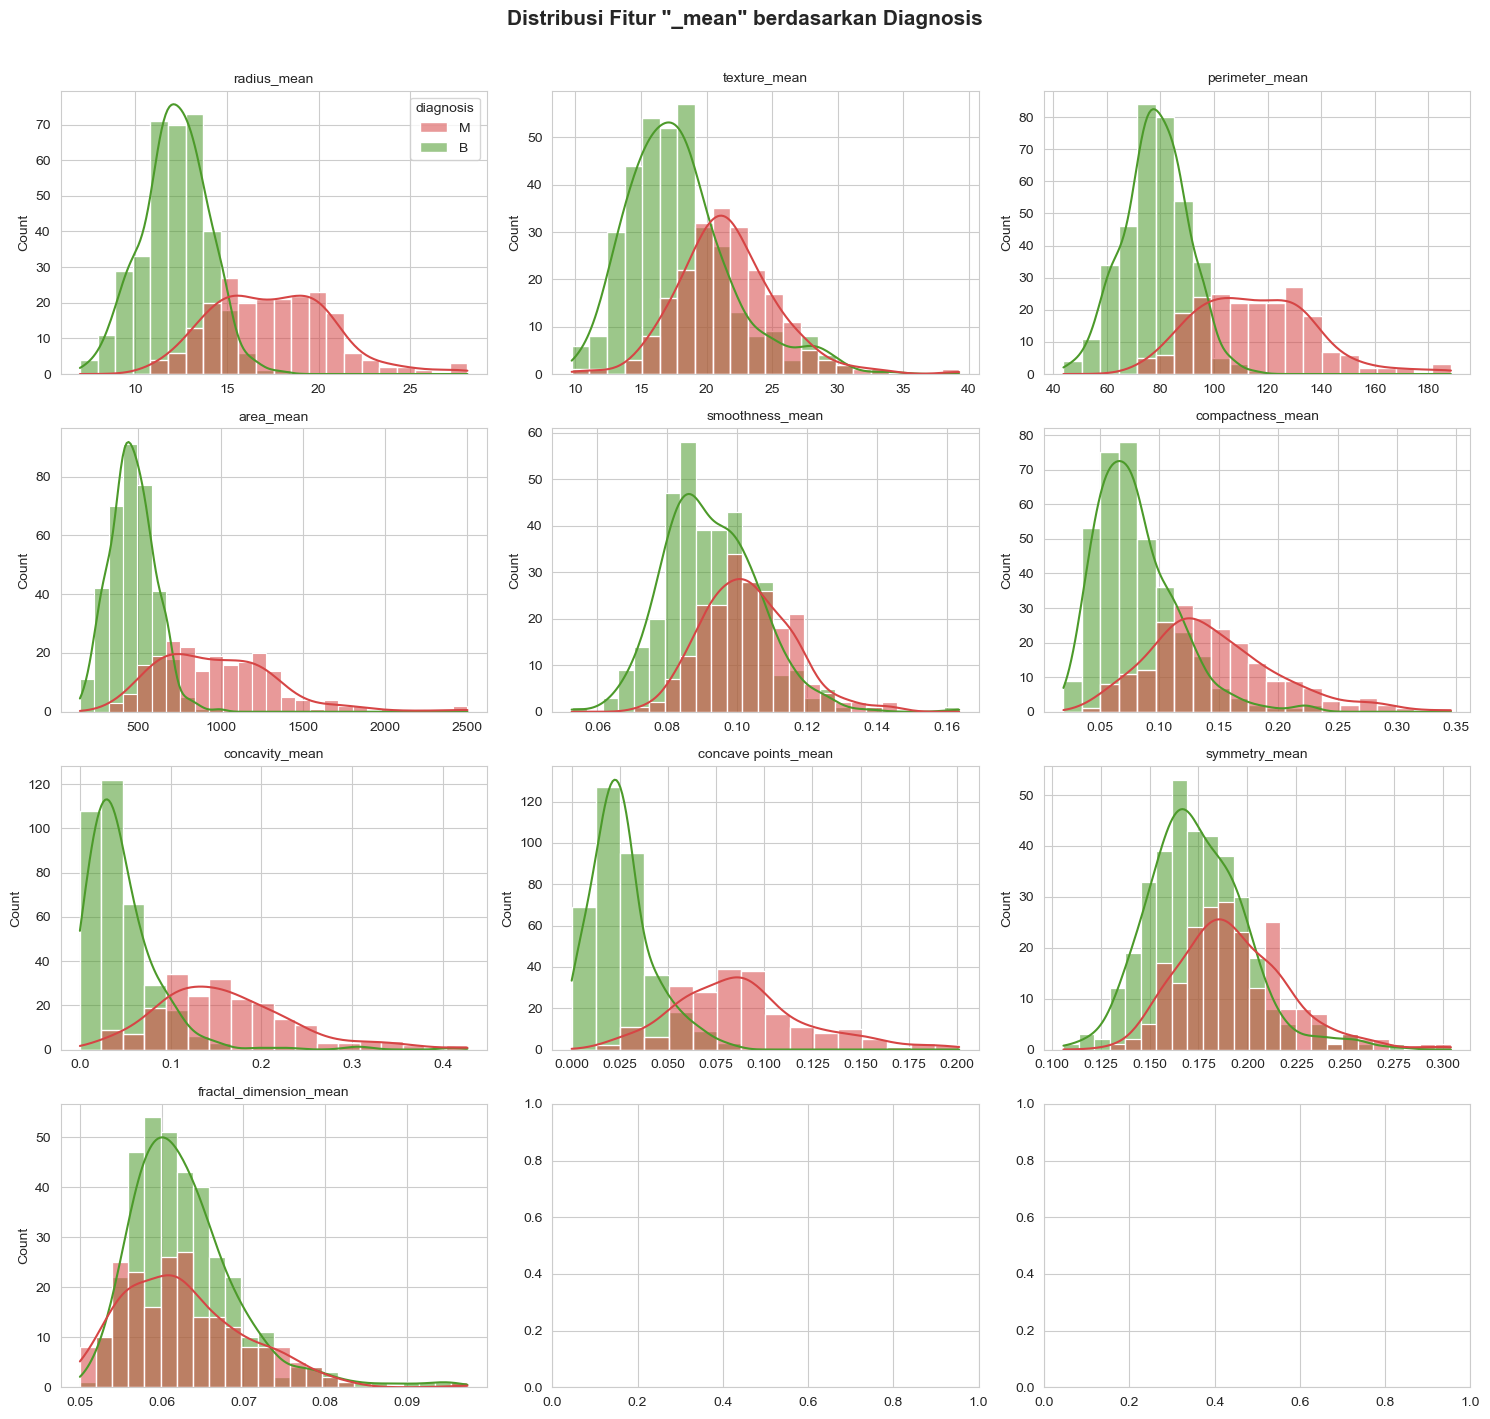

In [8]:

mean_features = [c for c in df.columns if c.endswith('_mean')]

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()
for i, col in enumerate(mean_features):
    sns.histplot(data=df, x=col, hue='diagnosis', kde=True, ax=axes[i],
                 palette={'B': '#4C9A2A', 'M': '#D64545'}, alpha=0.55, legend=(i==0))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
plt.suptitle('Distribusi Fitur "_mean" berdasarkan Diagnosis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 5. Correlation Heatmap

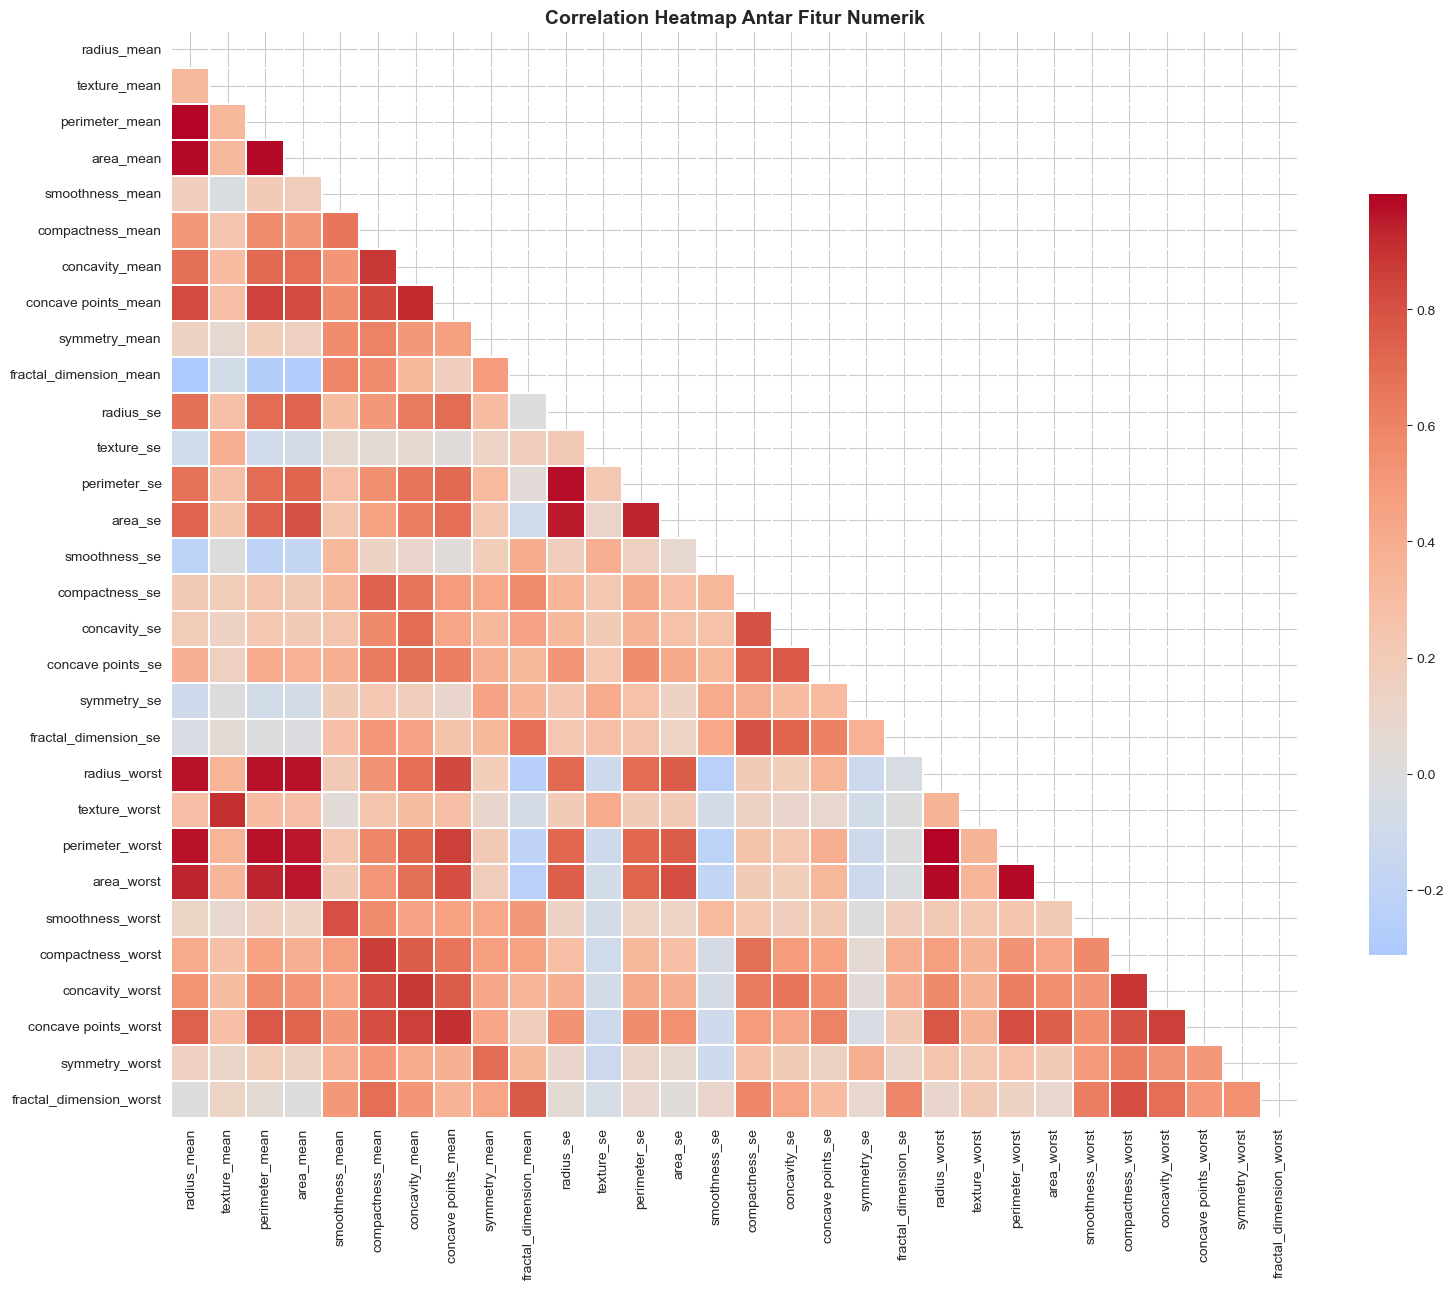

In [9]:

plt.figure(figsize=(16, 13))
corr = df.drop(columns=['diagnosis']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=False,
            linewidths=0.3, cbar_kws={'shrink': 0.7})
plt.title('Correlation Heatmap Antar Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Insight:** Fitur `_mean`, `_se`, `_worst` dari besaran fisik yang sama (radius, perimeter, area) berkorelasi tinggi (multikolinearitas). Model berbasis pohon relatif tahan terhadap ini; SVM diuntungkan dengan scaling.

## 6. Boxplot Fitur Kunci

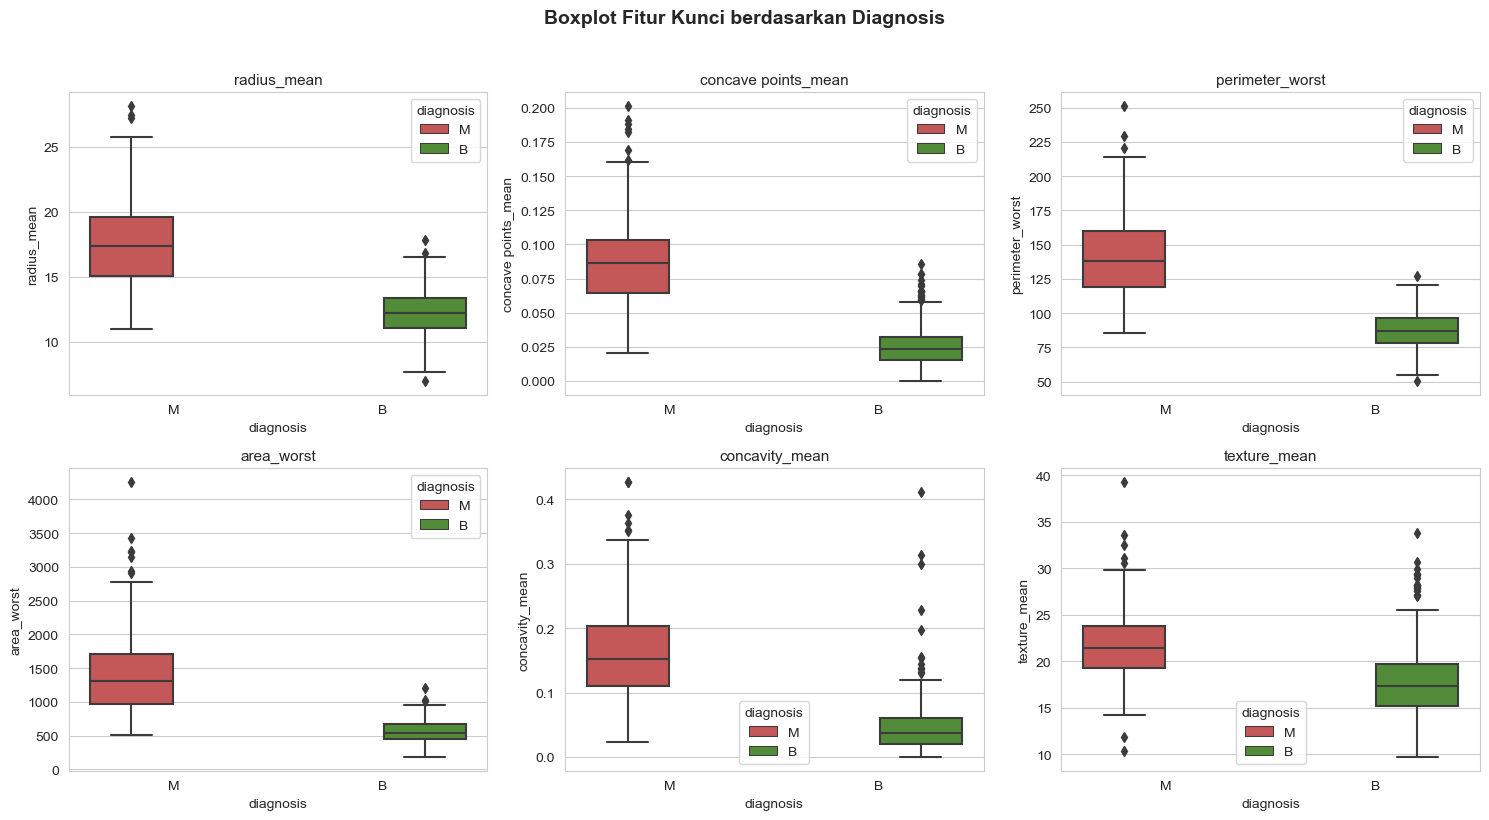

In [11]:

top_features = ['radius_mean', 'concave points_mean', 'perimeter_worst', 'area_worst',
                 'concavity_mean', 'texture_mean']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(top_features):
    sns.boxplot(data=df, x='diagnosis', y=col, hue='diagnosis', ax=axes[i],
                palette={'B': '#4C9A2A', 'M': '#D64545'})
    axes[i].set_title(col, fontsize=11)
plt.suptitle('Boxplot Fitur Kunci berdasarkan Diagnosis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 7. Pairplot Fitur Terpilih

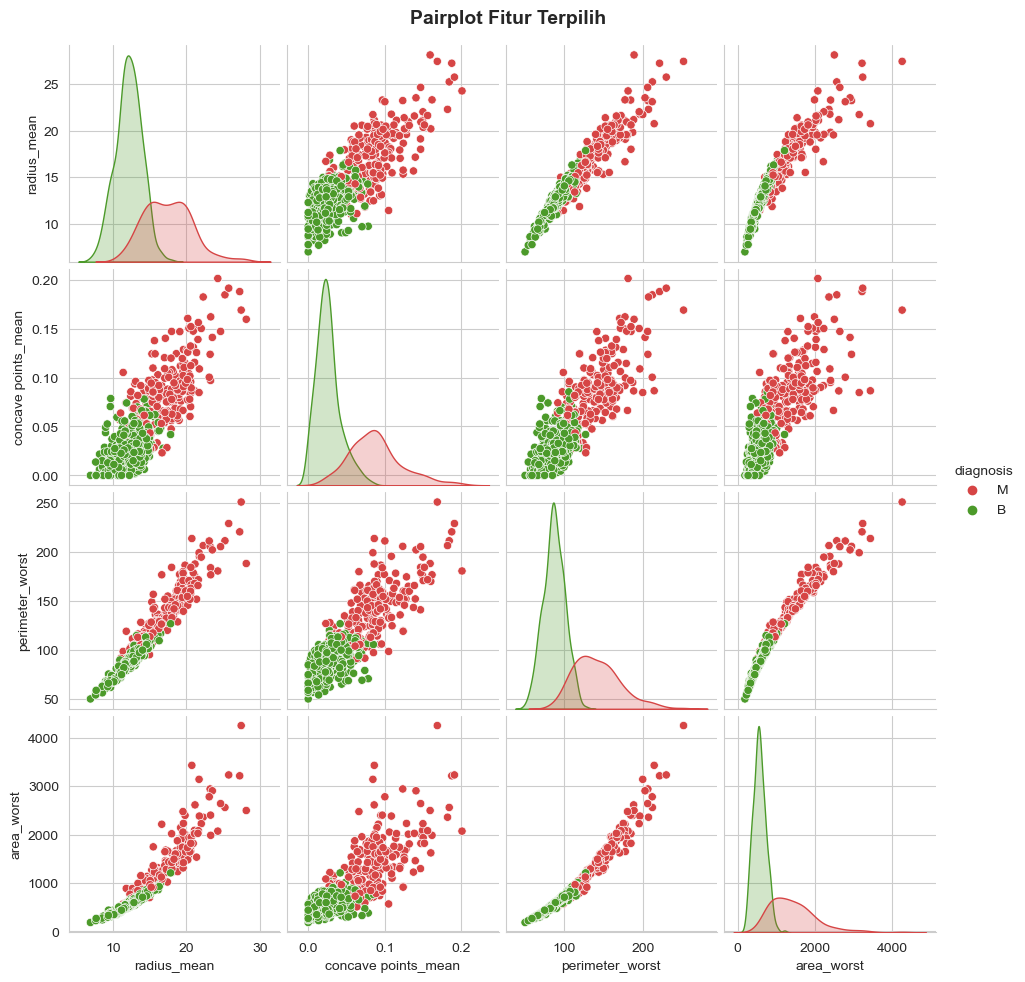

In [12]:

sns.pairplot(df, vars=['radius_mean', 'concave points_mean', 'perimeter_worst', 'area_worst'],
             hue='diagnosis', palette={'B': '#4C9A2A', 'M': '#D64545'}, diag_kind='kde', height=2.4)
plt.suptitle('Pairplot Fitur Terpilih', y=1.02, fontsize=14, fontweight='bold')
plt.show()


## Kesimpulan EDA

- Tidak ada missing value maupun duplikasi data.
- Fitur seperti `radius_mean`, `perimeter_mean`, `area_mean`, `concavity_mean`, dan `concave points_mean` menunjukkan pemisahan distribusi yang jelas antar kelas → berpotensi jadi prediktor kuat.
- Terdapat multikolinearitas tinggi antar fitur turunan (mean/se/worst dari radius, perimeter, area).
- Lanjut ke notebook pemodelan: `02_SVM.ipynb`, `03_XGBoost.ipynb`, `04_RandomForest.ipynb`.
